# Charting γ-secretase substrates by explainable AI

**Reproduce a published study with AAanalysis.** Where a *tutorial* teaches one tool and
a *protocol* teaches one workflow, a **use case** re-runs a real study end-to-end from
**bundled data only** (no downloads) — showing that a published result drops out of the
standard AAanalysis pipeline, and serving as a template you adapt to your own data.

This use case reproduces [Breimann25]_:

   Breimann and Kamp *et al.* (2025), *Charting γ-secretase substrates by explainable
   AI*, `Nature Communications 16, 5428 <https://www.nature.com/articles/s41467-025-60638-z>`__.

**Biological motivation.** γ-secretase is an intramembrane-cleaving protease that cuts the
transmembrane domain of single-span membrane proteins, releasing fragments that drive
signalling — and it is central to Alzheimer's disease (it generates the amyloid-β peptide
from the amyloid precursor protein, APP) and to cancer (it activates Notch receptors). Yet
out of hundreds of single-span membrane proteins, γ-secretase cleaves only a subset, and
**no consensus sequence motif** marks which ones. Worse, the data is **weakly labelled**: a
few dozen expert-curated substrates, only a handful of confirmed non-substrates, and
hundreds of proteins of unknown status. The study asks what physicochemically defines a
substrate, and how to predict substrates despite this.

**The AAanalysis pipeline.** *Comparative Physicochemical Profiling* (**CPP**) builds an
interpretable, position-resolved **signature** of the substrates over a redundancy-reduced
set of amino-acid scales (curated with **AAclust**); *deterministic Positive-Unlabelled
learning* (**dPULearn**) mines **reliable negatives** from the unlabelled pool to balance
the data; a tree model predicts substrate status; and **SHAP** explains individual
predictions at single-residue resolution.

**What this reproduces (key steps, simplified).** Sequence logos of the three protein
groups · an AAclust redundancy-reduced scale set · the CPP signature and feature map with
importances · dPULearn reliable-negative mining · a prediction benchmark (feature
engineering × data expansion) and feature-number optimization · single-residue SHAP
explanations for individual substrates.

**Simplifications (so it runs in seconds).** The study works over the full human N-out
proteome across ten model types with leave-one-out CV and three transmembrane annotations.
Here we use the bundled balanced ``DOM_GSEC`` set (63 substrates + 63 reliable
non-substrates) and the unlabelled ``DOM_GSEC_PU`` set (63 substrates + 631 others) with
their single embedded annotation, one tree ensemble, and 5-fold cross-validation. The
biology and the headline numbers reproduce; scaling up is the *Protocols* (P1, P4, P7-P10).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

sf = aa.SequenceFeature()

# Shared evaluator: 5-fold cross-validated balanced accuracy of a tree ensemble.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def balanced_acc(X, y):
    y = np.asarray(y)
    y_pred = cross_val_predict(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=cv)
    return balanced_accuracy_score(y, y_pred) * 100

## 1. Load the data

Two bundled **domain-level** (`DOM_`) datasets, one row per protein with the transmembrane
geometry and the pre-cut `jmd_n` / `tmd` / `jmd_c` parts:

- **`DOM_GSEC`** — the **curated** balanced set: 63 substrates (`label=1`) + 63 reliable
  non-substrates (`label=0`).
- **`DOM_GSEC_PU`** — the **positive-unlabelled** set: the same 63 substrates + 631
  *unlabelled* proteins of **unknown** status (`label=2`, the "others").

In [2]:
df_dom = aa.load_dataset(name="DOM_GSEC")        # curated: substrates + non-substrates
df_pu = aa.load_dataset(name="DOM_GSEC_PU")      # positive-unlabelled: substrates + others
y_dom = df_dom["label"].to_numpy()
y_pu = df_pu["label"].to_numpy()

print(f"DOM_GSEC (curated)  : {(y_dom == 1).sum()} substrates + {(y_dom == 0).sum()} non-substrates")
print(f"DOM_GSEC_PU (PU set): {(y_pu == 1).sum()} substrates + {(y_pu == 2).sum()} unlabelled 'others'")
aa.display_df(df=df_pu, n_rows=10, show_shape=True)

DOM_GSEC (curated)  : 63 substrates + 63 non-substrates
DOM_GSEC_PU (PU set): 63 substrates + 631 unlabelled 'others'
DataFrame shape: (694, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,P05067,MLPGLALLLLAAWTA...GYENPTYKFFEQMQN,1,701,723,FAEDVGSNKG,AIIGLMVGGVVIATVIVITLVML,KKKQYTSIHH
2,P14925,MAGRARSGLLLLLLG...EEEYSAPLPKPAPSS,1,868,890,KLSTEPGSGV,SVVLITTLLVIPVLVLLAIVMFI,RWKKSRAFGD
3,P70180,MRSLLLFTFSACVLL...RELREDSIRSHFSVA,1,477,499,PCKSSGGLEE,SAVTGIVVGALLGAGLLMAFYFF,RKKYRITIER
4,Q03157,MGPTSPAARGQGRRW...HGYENPTYRFLEERP,1,585,607,APSGTGVSRE,ALSGLLIMGAGGGSLIVLSLLLL,RKKKPYGTIS
5,Q06481,MAATGTAAAAATGRL...GYENPTYKYLEQMQI,1,694,716,LREDFSLSSS,ALIGLLVIAVAIATVIVISLVML,RKRQYGTISH
6,P35613,MAAALFVLLGFALLG...HQNDKGKNVRQRNSS,1,323,345,IITLRVRSHL,AALWPFLGIVAEVLVLVTIIFIY,EKRRKPEDVL
7,P35070,MDRAARCSGASSLPL...DITPINEDIEETNIA,1,119,141,LFYLRGDRGQ,ILVICLIAVMVVFIILVIGVCTC,CHPLRKRRKR
8,P09803,MGARCRSFSALLLLL...RFKKLADMYGGGEDD,1,711,733,GIVAAGLQVP,AILGILGGILALLILILLLLLFL,RRRTVVKEPL
9,P19022,MCRIAGALRTLLPLL...PRFKKLADMYGGGDD,1,724,746,RIVGAGLGTG,AIIAILLCIIILLILVLMFVVWM,KRRDKERQAK
10,P16070,MDKFWWHAAWGLCLV...DETRNLQNVDMKIGV,1,650,672,GPIRTPQIPE,WLIILASLLALALILAVCIAVNS,RRRCGQKKKL


## 2. Sequence logos of the three groups

Build a **probability sequence logo** for the substrates, the non-substrates, and the
unlabelled others. If a simple consensus motif marked substrates, it would jump out here.

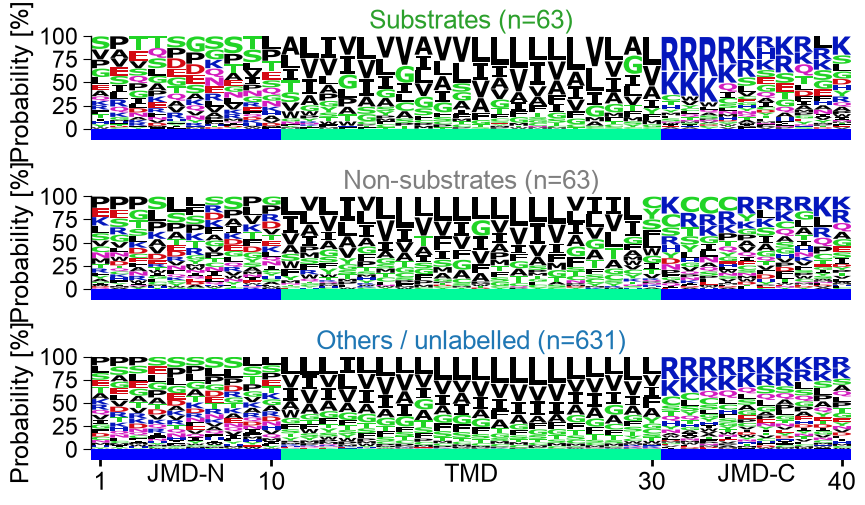

In [3]:
parts_dom_logo = sf.get_df_parts(df_seq=df_dom, list_parts=["jmd_n", "tmd", "jmd_c"])
parts_pu_logo = sf.get_df_parts(df_seq=df_pu, list_parts=["jmd_n", "tmd", "jmd_c"])

aal = aa.AAlogo(logo_type="probability")
TMD_LEN = 20
df_logo_sub = aal.get_df_logo(df_parts=parts_dom_logo, labels=y_dom, label_test=1, tmd_len=TMD_LEN)
df_logo_non = aal.get_df_logo(df_parts=parts_dom_logo, labels=y_dom, label_test=0, tmd_len=TMD_LEN)
df_logo_oth = aal.get_df_logo(df_parts=parts_pu_logo, labels=y_pu, label_test=2, tmd_len=TMD_LEN)

aa.plot_settings()
aal_plot = aa.AAlogoPlot(logo_type="probability", jmd_n_len=10, jmd_c_len=10)
aal_plot.multi_logo(
    list_df_logo=[df_logo_sub, df_logo_non, df_logo_oth],
    list_name_data=["Substrates (n=63)", "Non-substrates (n=63)", "Others / unlabelled (n=631)"],
    list_name_data_color=["tab:green", "tab:gray", "tab:blue"],
    figsize_per_logo=(9, 1.8),
)
plt.tight_layout()
plt.show()

All three logos look essentially the same — a hydrophobic TMD flanked by a
lysine/arginine-rich JMD-C. There is **no consensus motif** that picks out substrates; the
discriminating signal is *physicochemical and position-dependent*, which is what CPP reads.

## 3. AAclust: a redundancy-reduced scale set

CPP describes each position by amino-acid **scales** (physicochemical property indices).
The bundled set has **586** scales, but many are near-duplicates. **AAclust** clusters them
and keeps one representative per cluster — here with **agglomerative, complete-linkage**
clustering, as in the study. We compare a few set sizes and keep **133** representative
scales (the study's main set).

In [4]:
df_scales = aa.load_scales()   # 20 amino acids x 586 scales
X_scales = df_scales.T

aac = aa.AAclust(model_class=AgglomerativeClustering, model_kwargs={"linkage": "complete"})
sizes = [50, 100, 133, 200]
list_labels = [aac.fit(X_scales, n_clusters=k).labels_ for k in sizes]
df_eval = aac.eval(X_scales, list_labels=list_labels,
                   names_datasets=[f"Set {i+1} (n={k})" for i, k in enumerate(sizes)])
aa.display_df(df=df_eval, n_rows=10, show_shape=True)

DataFrame shape: (4, 5)


,name,n_clusters,BIC,CH,SC
1,Set 1 (n=50),50,36.326619,31.762686,0.146554
2,Set 2 (n=100),100,-1328.884793,24.023842,0.150068
3,Set 3 (n=133),133,-2382.239699,22.269659,0.165686
4,Set 4 (n=200),200,-4604.826550,21.556305,0.174962


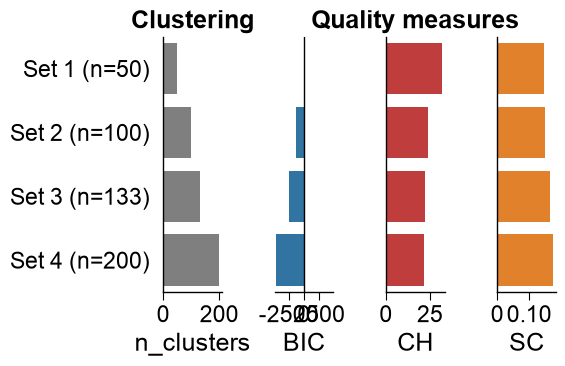

In [5]:
aa.plot_settings()
aa.AAclustPlot().eval(df_eval=df_eval)
plt.tight_layout()
plt.show()

In [6]:
# Keep the 133-scale representative set for all downstream feature engineering.
df_scales_red = aac.select_scales(df_scales, n_clusters=133)
print(f"reduced scale set: {df_scales_red.shape[1]} scales (from {df_scales.shape[1]})")

reduced scale set: 133 scales (from 586)


## 4. CPP + TreeModel: the physicochemical signature

CPP contrasts the **test group** (substrates, `label=1`) against the **reference group**
(non-substrates, `label=0`), splitting each sequence into **parts**, applying **splits**,
and averaging a **scale** over the selected positions; it keeps the `Part-Split-Scale`
features that separate the groups best — the **signature**. A `TreeModel` then ranks them by
importance. (Mechanics: the `CPP` and `TreeModel` tutorials.)

In [7]:
parts_dom = sf.get_df_parts(df_seq=df_dom)   # default TMD-centric composite parts
df_feat = aa.CPP(df_parts=parts_dom, df_scales=df_scales_red).run(labels=list(y_dom), n_filter=100, n_jobs=1)

X_cpp_dom = sf.feature_matrix(features=df_feat["feature"], df_parts=parts_dom, df_scales=df_scales_red)
df_feat = aa.TreeModel().fit(X_cpp_dom, labels=y_dom).add_feat_importance(df_feat=df_feat)
print(f"signature: {df_feat.shape[0]} features")
aa.display_df(
    df=df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc", "feat_importance"]],
    n_rows=8, show_shape=True,
)

signature: 100 features
DataFrame shape: (100, 6)


,feature,category,subcategory,mean_dif,abs_auc,feat_importance
1,"TMD_C_JMD_C-Pat...,15)-ROBB760103",Conformation,α-helix,0.107000,0.354000,3.368000
2,"TMD_C_JMD_C-Seg...6,9)-ZIMJ680104",Energy,Isoelectric point,0.268000,0.352000,4.456000
3,"TMD_C_JMD_C-Seg...4,9)-ROBB760113",Conformation,β-turn,-0.337000,0.349000,1.955000
4,"TMD_C_JMD_C-Seg...2,3)-KANM800103",Conformation,α-helix,0.113000,0.342000,1.668000
5,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,0.205000,0.336000,1.846000
6,"TMD_C_JMD_C-Seg...2,3)-VASM830101",Conformation,Unclassified (Conformation),0.139000,0.335000,1.172000
7,"TMD_C_JMD_C-Seg...6,9)-WERD780103",Energy,Unclassified (Energy),-0.122000,0.329000,2.084000
8,"TMD_C_JMD_C-Seg...4,8)-ROBB760113",Conformation,β-turn,-0.261000,0.327000,2.214000


The **feature map** shows the whole signature at once: rows = scale subcategories,
columns = positions along the parts, colour = direction & strength of the substrate-vs-non-
substrate difference, top bars = cumulative importance. The signal concentrates in the
**cleavage region** (C-terminal TMD into JMD-C) and is dominated by **conformational**
properties — the study's central biological readout.

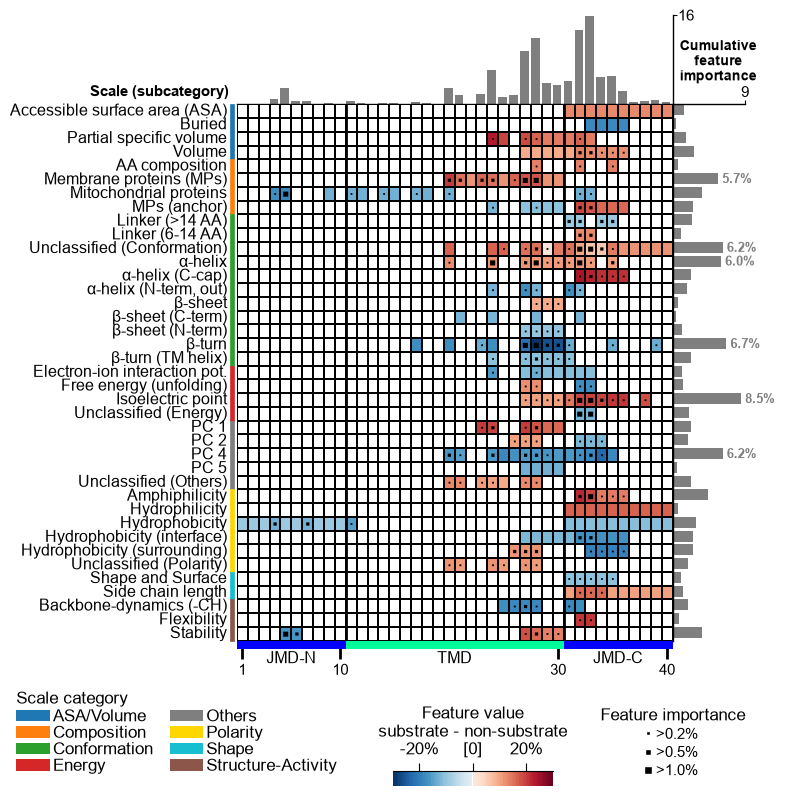

In [8]:
cpp_plot = aa.CPPPlot()
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

## 5. dPULearn: mine reliable negatives

The 63 curated non-substrates were not all known upfront: only **14** were experimentally
confirmed; the other **49** were predicted by dPULearn from the unlabelled pool. The bundled
data still encodes that split — the curated negatives that never appear among the unlabelled
`DOM_GSEC_PU` "others" are exactly the 14 experimentally-known ones. **dPULearn** projects
the proteins into the CPP feature space and labels the unlabelled points **most distant from
the positives** as **reliable negatives**, deterministically, extending the 14 to a balanced 63.

In [9]:
known_neg = sorted(set(df_dom.loc[y_dom == 0, "entry"]) - set(df_pu.loc[y_pu == 2, "entry"]))
df_known = df_dom[df_dom["entry"].isin(known_neg)]
df_pos = df_pu[df_pu["label"] == 1]
df_others = df_pu[df_pu["label"] == 2]

def cpp_X(df):
    return sf.feature_matrix(features=df_feat["feature"], df_parts=sf.get_df_parts(df_seq=df),
                             df_scales=df_scales_red)
X_cpp_pos, X_cpp_known, X_cpp_oth = cpp_X(df_pos), cpp_X(df_known), cpp_X(df_others)

n_mine = 63 - len(known_neg)
X_pool = np.vstack([X_cpp_pos, X_cpp_oth])
y_pool = np.array([1] * len(X_cpp_pos) + [2] * len(X_cpp_oth))
dpul = aa.dPULearn(random_state=42)
dpul.fit(X=X_pool, labels=y_pool, n_unl_to_neg=n_mine)
mined_others = np.asarray(dpul.labels_)[len(X_cpp_pos):] == 0
print(f"positives: {len(df_pos)} | experimentally-known negatives: {len(known_neg)} "
      f"| dPULearn-mined reliable negatives: {int(mined_others.sum())}")

positives: 63 | experimentally-known negatives: 14 | dPULearn-mined reliable negatives: 49


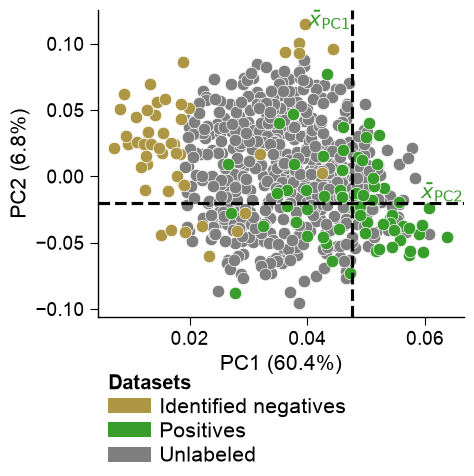

In [10]:
aa.plot_settings(font_scale=0.85)
aa.dPULearnPlot().pca(df_pu=dpul.df_pu_, labels=np.asarray(dpul.labels_))
plt.tight_layout()
plt.show()

The positives (green) cluster on one side of the CPP feature space; dPULearn picks
the unlabelled points (grey) farthest from them as **reliable negatives** (gold).

## 6. Sequence logo of the reliable negatives

What do the mined negatives look like? Their logo, beside the substrates', shows dPULearn
selected coherent membrane proteins (not noise) — yet still with no single distinguishing
motif, reinforcing that the difference is physicochemical.

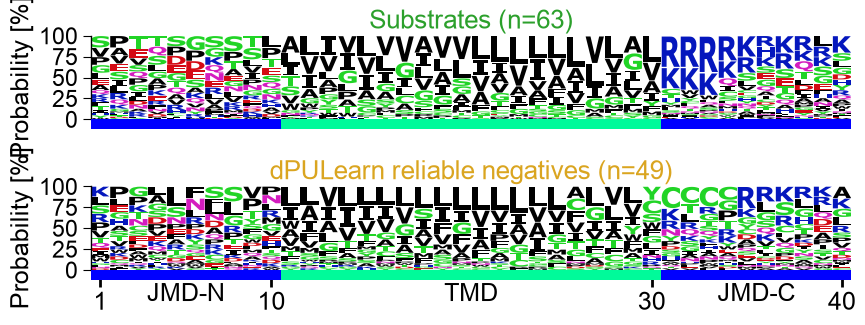

In [11]:
df_mined = df_others.iloc[np.where(mined_others)[0]].reset_index(drop=True)
parts_mined = sf.get_df_parts(df_seq=df_mined, list_parts=["jmd_n", "tmd", "jmd_c"])
df_logo_rel = aal.get_df_logo(df_parts=parts_mined, tmd_len=TMD_LEN)

aa.plot_settings()
aal_plot.multi_logo(
    list_df_logo=[df_logo_sub, df_logo_rel],
    list_name_data=["Substrates (n=63)", "dPULearn reliable negatives (n=49)"],
    list_name_data_color=["tab:green", "goldenrod"],
    figsize_per_logo=(9, 1.8),
)
plt.tight_layout()
plt.show()

## 7. Prediction evaluation

### Optimizing the feature and negative counts

How many CPP features and how many dPULearn negatives are enough? Sweep both and read
5-fold balanced accuracy as a heatmap (always 63 positives + the 14 known negatives,
extended by the top dPULearn-mined negatives).

In [12]:
feat_list = df_feat["feature"]
n_feats = [25, 50, 75, 100]
n_negs = [20, 35, 49, 63]
heat = np.zeros((len(n_feats), len(n_negs)))
for i, nf in enumerate(n_feats):
    feats = feat_list.iloc[:nf]
    Xp = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_pos), df_scales=df_scales_red)
    Xk = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_known), df_scales=df_scales_red)
    Xo = sf.feature_matrix(features=feats, df_parts=sf.get_df_parts(df_seq=df_others), df_scales=df_scales_red)
    d = aa.dPULearn(random_state=42)
    d.fit(X=np.vstack([Xp, Xo]), labels=np.array([1]*len(Xp) + [2]*len(Xo)), n_unl_to_neg=max(n_negs))
    order = np.where(np.asarray(d.labels_)[len(Xp):] == 0)[0]
    for j, nn in enumerate(n_negs):
        take = min(nn, len(order))
        X = np.vstack([Xp, Xk, Xo[order[:take]]])
        heat[i, j] = balanced_acc(X, [1]*len(Xp) + [0]*(len(Xk) + take))
print("best balanced accuracy: %.1f%%" % heat.max())

best balanced accuracy: 92.1%


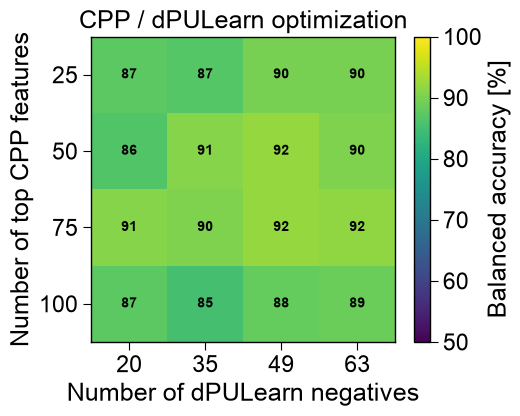

In [13]:
aa.plot_settings()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(heat, cmap="viridis", aspect="auto", vmin=50, vmax=100)
ax.set_xticks(range(len(n_negs))); ax.set_xticklabels(n_negs)
ax.set_yticks(range(len(n_feats))); ax.set_yticklabels(n_feats)
ax.set_xlabel("Number of dPULearn negatives"); ax.set_ylabel("Number of top CPP features")
ax.set_title("CPP / dPULearn optimization")
for i in range(len(n_feats)):
    for j in range(len(n_negs)):
        ax.text(j, i, f"{heat[i, j]:.0f}", ha="center", va="center",
                color="white" if heat[i, j] < 80 else "black", fontsize=10, weight="bold")
fig.colorbar(im, ax=ax, label="Balanced accuracy [%]")
plt.tight_layout()
plt.show()

### Comparing against the baseline

Two axes, as in the study. Always train on the 63 positives; vary the **feature method**
(a scale-average baseline — each scale averaged over the whole sequence, no positional
splits — vs. the **CPP** signature) and the **data expansion** (14 known negatives only /
+49 random others / +49 dPULearn-mined reliable negatives). CPP beats the baseline at every
column, and dPULearn beats *no* and *random* expansion: it is *interpretable features and
reliable negatives*, not just more data, that reach the study's accuracy.

In [14]:
def scale_X(df):
    seqs = (df["jmd_n"] + df["tmd"] + df["jmd_c"]).to_list()
    return np.array([df_scales_red.loc[[a for a in s if a in df_scales_red.index]].mean(axis=0).values
                     for s in seqs])
X_sc_pos, X_sc_known, X_sc_oth = scale_X(df_pos), scale_X(df_known), scale_X(df_others)

def bench(X_pos, X_known, X_oth):
    none = balanced_acc(np.vstack([X_pos, X_known]), [1]*len(X_pos) + [0]*len(X_known))
    rnd = []
    for seed in range(3):
        pick = np.random.default_rng(seed).choice(len(X_oth), size=n_mine, replace=False)
        rnd.append(balanced_acc(np.vstack([X_pos, X_known, X_oth[pick]]),
                                [1]*len(X_pos) + [0]*(len(X_known) + n_mine)))
    dpu = balanced_acc(np.vstack([X_pos, X_known, X_oth[mined_others]]),
                       [1]*len(X_pos) + [0]*(len(X_known) + int(mined_others.sum())))
    return [none, float(np.mean(rnd)), dpu]

res_scale = bench(X_sc_pos, X_sc_known, X_sc_oth)
res_cpp = bench(X_cpp_pos, X_cpp_known, X_cpp_oth)
cols = ["No expansion\n(14 known)", "Random\nexpansion", "dPULearn\nexpansion"]
print("Scale-based :  " + "  ".join(f"{v:5.1f}%" for v in res_scale))
print("CPP         :  " + "  ".join(f"{v:5.1f}%" for v in res_cpp))

Scale-based :   61.1%   59.8%   74.6%
CPP         :   70.6%   73.5%   93.7%


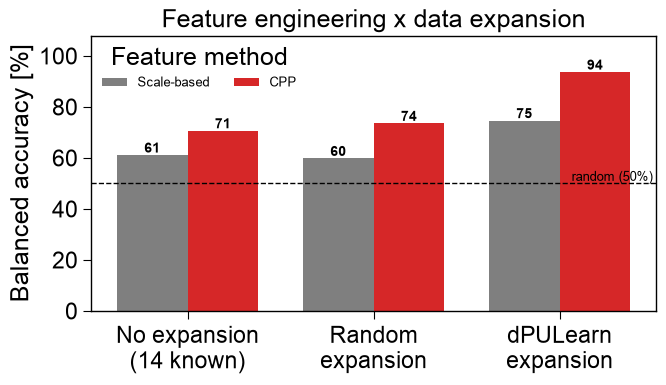

In [15]:
aa.plot_settings()
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(cols)); w = 0.38
b1 = ax.bar(x - w/2, res_scale, w, label="Scale-based", color="tab:gray")
b2 = ax.bar(x + w/2, res_cpp, w, label="CPP", color="tab:red")
ax.axhline(50, ls="--", color="black", lw=1); ax.text(2.5, 51, "random (50%)", ha="right", fontsize=9)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{b.get_height():.0f}",
                ha="center", fontsize=10, weight="bold")
ax.set_xticks(x); ax.set_xticklabels(cols)
ax.set_ylabel("Balanced accuracy [%]"); ax.set_ylim(0, 108)
ax.set_title("Feature engineering x data expansion")
ax.legend(title="Feature method", loc="upper left", ncol=2, fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## 8. Explaining single substrates with SHAP

CPP describes the *group*; **SHAP** explains *one protein*. Fitting a `ShapModel` on the CPP
features and reading out per-residue feature impact shows *where* in a given substrate the
substrate-defining signal sits. We do this for **APP** (the amyloid precursor protein, the
Alzheimer-relevant substrate) and **N-cadherin (CDH2)**, both in the bundled set.

*(Notch — the canonical cancer-relevant substrate — is not in the bundled ``DOM_GSEC``
subset; it lives in the study's full proteome dataset.)*

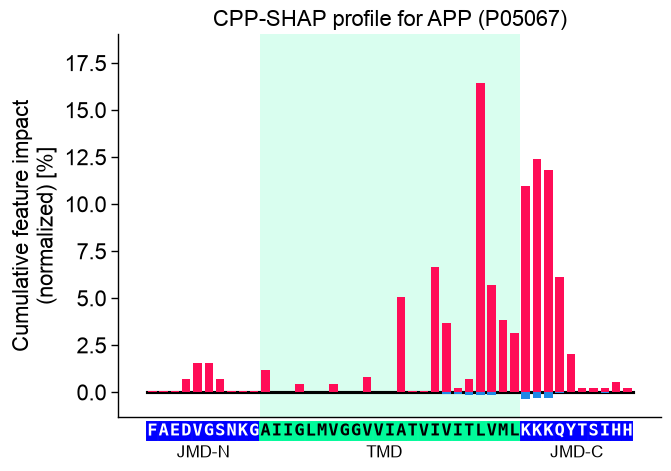

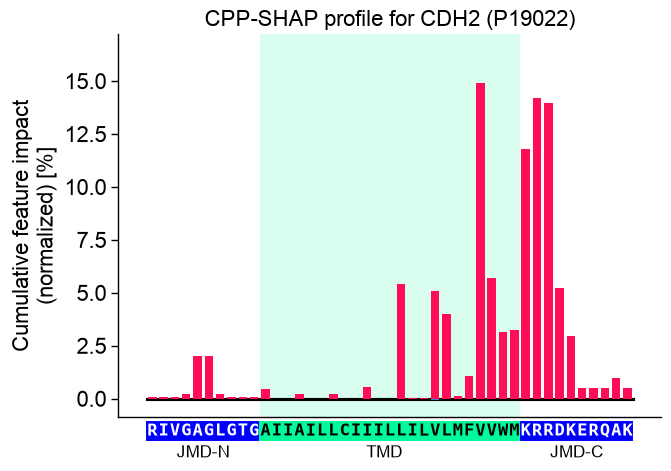

In [16]:
X_shap = sf.feature_matrix(features=df_feat["feature"], df_parts=parts_dom, df_scales=df_scales_red)
sm = aa.ShapModel(random_state=42)
sm.fit(X_shap, labels=list(y_dom))

samples = {"APP": "P05067", "CDH2": "P19022"}
positions = [int(np.where(df_dom["entry"].values == acc)[0][0]) for acc in samples.values()]
names = list(samples)
df_feat = sm.add_sample_mean_dif(X_shap, labels=list(y_dom), df_feat=df_feat,
                                 samples=positions, names=names)
df_feat = sm.add_feat_impact(df_feat=df_feat, samples=positions, names=names)

for name, acc in samples.items():
    seq_kws = sf.get_seq_kws(df_seq=df_dom, df_parts=parts_dom, sample=acc)
    aa.plot_settings(font_scale=0.9)
    aa.CPPPlot().profile(df_feat=df_feat, shap_plot=True, col_imp=f"feat_impact_{name}", **seq_kws)
    plt.title(f"CPP-SHAP profile for {name} ({acc})")
    plt.tight_layout()
    plt.show()

For both substrates the per-residue impact peaks in the **cleavage region** (C-terminal
TMD into the JMD-C), pinpointing the residues that make each protein a substrate — the
single-residue interpretability that motivates the "explainable AI" in the study's title.

## Summary

Reproduced from bundled data, in seconds, the full arc of the study:

- **No motif** — substrate, non-substrate and "other" logos are indistinguishable; the
  signal is physicochemical, not a letter pattern.
- **AAclust** reduces 586 redundant scales to a representative set of 133.
- **CPP + TreeModel** yield an interpretable signature concentrated in the cleavage region
  and dominated by conformational properties.
- **dPULearn** mines reliable negatives from the unlabelled pool to balance the data.
- **Prediction** — CPP beats a scale-average baseline at every setting, dPULearn beats no-
  and random-expansion, and the optimized CPP + dPULearn combination reaches ~90%+ balanced
  accuracy, matching the study.
- **SHAP** explains individual substrates (APP, CDH2) at single-residue resolution.

**Scale it up.** To approach the full study — the imbalanced proteome, multi-model
leave-one-out CV, and proteome-wide prediction — follow the **Protocols**: *P1 (CPP
signature)*, *P4 (prediction tasks)*, *P7-P8 (selection & prediction)*, and *P9-P10
(interpretability & validation)*.

   Breimann and Kamp *et al.* (2025), *Charting γ-secretase substrates by explainable AI*,
   `Nature Communications 16, 5428 <https://www.nature.com/articles/s41467-025-60638-z>`__.